# Construcción incremental del grafo de conocimiento con criterio de parada por cuatro indicadores ortogonales

Este experimento construye el grafo de conocimiento de forma incremental sobre la totalidad del corpus DICAT (2375 textos) e introduce, por primera vez, un criterio de parada basado en cuatro indicadores ortogonales.

Se parte de las tripletas extraídas con mREBEL y representadas mediante embeddings construidos a partir de los tipos de las entidades (tipo de cabeza, relación y tipo de cola). Los documentos se incorporan uno a uno, en orden aleatorio reproducible (semilla fija), y tras cada incorporación se reagrupan con HDBSCAN todas las relaciones acumuladas.

En cada iteración se calculan cuatro indicadores que vigilan, por separado, aspectos distintos del proceso:

- productividad: fracción de las relaciones nuevas que aporta conocimiento nuevo,
- estabilidad estructural (ARI): conservación de la agrupación de lo ya consolidado,
- degradación (C→N): relaciones que pasan de un grupo al ruido,
- consolidación (N→C): relaciones que pasan del ruido a un grupo.

Los indicadores se agregan en una ventana de iteraciones y el proceso se detiene cuando los cuatro cumplen sus umbrales a la vez. Tras la parada se aplica una fase de rescate del ruido, que agrupa entre sí las relaciones de ruido equivalentes por similitud coseno alta.

El clustering se realiza en el espacio original de 384 dimensiones, sin reducción de dimensionalidad.

In [ ]:
# ============================================================
# EXPERIMENTO 9
# Construcción incremental del grafo de conocimiento con criterio de parada por cuatro indicadores ortogonales
# ============================================================
# En esta celda se centralizan los parámetros principales del
# experimento para que el notebook sea más fácil de reproducir
# y modificar.

# Identificador del experimento.
# Se usará como prefijo en los ficheros de salida.
EXPERIMENTO = "Exp08"

#from google.colab import drive
#drive.mount('/content/drive')

# Carpeta donde se guardarán los resultados generados.
OUTPUT_DIR = "../Output/experiments"

#OUTPUT_DIR = (
#    "/content/drive/MyDrive/TFM/experiments"
#)


# Modelo de embeddings utilizado para representar semánticamente
# las oraciones en las que aparece cada verbo.
MODEL_EMBEDDINGS = "paraphrase-multilingual-MiniLM-L12-v2"

# Parámetros principales de HDBSCAN.
# min_cluster_size define el tamaño mínimo que debe tener un cluster.
MIN_CLUSTER_SIZE = 4

# min_samples controla la exigencia del algoritmo para considerar
# un punto como parte de una zona densa.
MIN_SAMPLES = 2

# Semilla para mantener reproducibilidad en aquellos procesos
# que puedan depender de aleatoriedad.
RANDOM_STATE = 42

In [17]:
# ============================================================
# IMPORTS
# ============================================================

import os
import re

import pandas as pd
import numpy as np

import spacy

from sentence_transformers import SentenceTransformer

import hdbscan

import matplotlib.pyplot as plt


# ============================================================
# CREACIÓN DE CARPETAS DE SALIDA
# ============================================================

# Si la carpeta Outputs no existe, se crea automáticamente.
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# CARGA DEL MODELO DE EMBEDDINGS
# ============================================================

# Modelo multilingüe utilizado para representar semánticamente
# las oraciones extraídas del corpus.
#model_embeddings = SentenceTransformer(MODEL_EMBEDDINGS)


print("Configuración cargada correctamente.")

Configuración cargada correctamente.


In [ ]:
# ============================================================
# CARGA DEL DATASET
# ============================================================

# Ruta del dataset limpio procedente del TFM anterior.
DATASET_PATH = "../Data/InformacionAutores10%.csv"

# Carga del CSV.
df = pd.read_csv(DATASET_PATH, sep=";")

print("Dataset cargado correctamente.")
print(f"Número de registros: {len(df)}")
print(f"Número de columnas: {df.shape[1]}")

# Mostrar primeras filas.
df.head()



Dataset cargado correctamente.
Número de registros: 2375
Número de columnas: 4


,id,Nombre,Anyo,Informacion
0,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d..."
1,2,NaN,Introducción,"Desconocemos el nombre de esta actriz, que es ..."
2,40,"Aburtes, José de",1678,Se ahogó en la Barra de Huelva estando en la c...
3,40,"Aburtes, José de",Apostilla,—¿Distinto de José Abraldes?—.
4,45,"Acosta (o de los Reyes, o Rueda, o Sotomayor, ...",1630,"Consta una carta de pago, fechada en Madrid el..."


In [ ]:
# ============================================================
# SELECCIÓN DE LA COLUMNA TEXTUAL
# ============================================================
# Para este experimento utilizamos la columna Informacion,

TEXT_COLUMN = "Informacion"

# Comprobamos cuántos valores nulos hay en la columna seleccionada.
num_nulls = df[TEXT_COLUMN].isna().sum()

print(f"Columna textual seleccionada: {TEXT_COLUMN}")
print(f"Valores nulos en la columna: {num_nulls}")

# Nos quedamos únicamente con los registros que tienen texto válido.
df_text = df.dropna(subset=[TEXT_COLUMN]).copy()

print(f"Número de registros con texto válido: {len(df_text)}")

df_text[[TEXT_COLUMN]].head()

Columna textual seleccionada: Informacion
Valores nulos en la columna: 0
Número de registros con texto válido: 2375


,Informacion
0,"Según la «Genealogía», que recoge la noticia d..."
1,"Desconocemos el nombre de esta actriz, que es ..."
2,Se ahogó en la Barra de Huelva estando en la c...
3,—¿Distinto de José Abraldes?—.
4,"Consta una carta de pago, fechada en Madrid el..."


In [ ]:
print(df_text.loc[0, TEXT_COLUMN])
df_text.columns

Según la «Genealogía», que recoge la noticia del Libro de las Cuentas de la Cofradía de Nuestra Señora de la Novena, 'la Cosita' fue enterrada en la parroquia de Antón Martín en Madrid (G, 526).


Index(['id', 'Nombre', 'Anyo', 'Informacion'], dtype='object')

In [ ]:
# ============================================================
# COMPROBACION QUE LA CLAVE UNICA DEL DATASET ES ID - ANYO
# ============================================================

duplicados = (
    df_text
    .groupby(["id", "Anyo"])
    .size()
    .reset_index(name="count")
)

# Mostrar solo las claves repetidas
duplicados = duplicados[duplicados["count"] > 1]

print(duplicados)

es_clave_unica = not df_text.duplicated(subset=["id", "Anyo"]).any()

print("es_clave_unica: " ,es_clave_unica)

Empty DataFrame
Columns: [id, Anyo, count]
Index: []
es_clave_unica:  True


In [ ]:
# ============================================================
# SEPARACIÓN DE LOS TEXTOS EN FRASES SEPARADAS
# ============================================================


# Modelo lingüístico de spaCy para español.
nlp = spacy.load("es_core_news_lg")


# Lista donde guardaremos las nuevas filas
rows = []

# Recorrer cada fila del dataframe original
for _, row in df_text.iterrows():

    texto = row["Informacion"]

    # Procesar texto
    doc = nlp(texto)

    # Obtener frases
    for sent in doc.sents:

        rows.append({
            "id": row["id"],
            "Nombre": row["Nombre"],
            "Anyo": row["Anyo"],
            "Frase": sent.text.strip()
        })

# Crear nuevo dataframe
df_sentences = pd.DataFrame(rows)

# Mostrar resultado
print(df_sentences.head())



   id                                             Nombre          Anyo  \
0   2                                                NaN          1642   
1   2                                                NaN  Introducción   
2  40                                   Aburtes, José de          1678   
3  40                                   Aburtes, José de     Apostilla   
4  45  Acosta (o de los Reyes, o Rueda, o Sotomayor, ...          1630   

                                               Frase  
0  Según la «Genealogía», que recoge la noticia d...  
1  Desconocemos el nombre de esta actriz, que es ...  
2  Se ahogó en la Barra de Huelva estando en la c...  
3                     —¿Distinto de José Abraldes?—.  
4  Consta una carta de pago, fechada en Madrid el...  


In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

# print(df_sentences[df_sentences["id"] == 45])

"""
print(
df_sentences[
    (df_sentences["id"] == 45) &
    (df_sentences["Anyo"] == 1605)
]
)
"""

'\nprint(\ndf_sentences[\n    (df_sentences["id"] == 45) &\n    (df_sentences["Anyo"] == 1605)\n]\n)\n'

In [ ]:
# ============================================================
# CONFIGURACION MODELO MREBEL - MULTILINGÜE
# ============================================================

import pandas as pd
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer



# Load model and tokenizer - spanish
tokenizer = AutoTokenizer.from_pretrained(
    "Babelscape/mrebel-large",
    src_lang="es_XX",
    tgt_lang="tp_XX"
)

# explora 3 posibles generaciones y devuelve las 3 mejores
model = AutoModelForSeq2SeqLM.from_pretrained("Babelscape/mrebel-large")
gen_kwargs = {
    "max_length": 256,
    "length_penalty": 0,
    "num_beams": 3, 
    "num_return_sequences": 3,
}

def extract_mrebel_triplets(text):
    triplets = []

    text = (
        text.replace("<s>", "")
            .replace("</s>", "")
            .replace("<pad>", "")
            .replace("tp_XX", "")
            .strip()
    )

    parts = text.split("<triplet>")

    for part in parts:
        part = part.strip()
        if not part:
            continue

        match = re.match(
            r"(.+?)\s+<([^>]+)>\s+(.+?)\s+<([^>]+)>\s+(.+)",
            part
        )

        if match:
            head, head_type, tail, tail_type, relation = match.groups()

            triplets.append({
                "head": head.strip(),
                "head_type": head_type.strip(),
                "tail": tail.strip(),
                "tail_type": tail_type.strip(),
                "type": relation.strip()
            })

    return triplets


def get_mrebel_triplets_for_sentence(text):
    model_inputs = tokenizer(
        text,
        max_length=256,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    generated_tokens = model.generate(
        model_inputs["input_ids"].to(model.device),
        attention_mask=model_inputs["attention_mask"].to(model.device),
        forced_bos_token_id=tokenizer.convert_tokens_to_ids("tp_XX"),
        max_length=256,
        length_penalty=0,
        num_beams=3,
        num_return_sequences=3
    )

    decoded_preds = tokenizer.batch_decode(
        generated_tokens,
        skip_special_tokens=False
    )

    triplets = [
        extract_mrebel_triplets(pred)
        for pred in decoded_preds
    ]

    return triplets

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# EJECUCION DEL MODEL MREBEL PARA SACAR LAS TRIPLETAS DE CADA FRASE
# ============================================================

from datetime import datetime
import time
import os
from google.colab import files

inicio_total = time.time()

BATCH_SIZE = 25

if "mrebel_outputs" not in df_sentences.columns:
    df_sentences["mrebel_outputs"] = None

duplas = (
    df_sentences[df_sentences["mrebel_outputs"].isna()][["id", "Anyo"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

total_duplas = len(duplas)

print(f"Total Duplas: {total_duplas}")

os.makedirs(OUTPUT_DIR, exist_ok=True)

for inicio_lote in range(0, total_duplas, BATCH_SIZE):

    inicio = time.time()

    fin_lote = min(inicio_lote + BATCH_SIZE, total_duplas)

    duplas_lote = duplas.iloc[inicio_lote:fin_lote]

    print(
        f"Procesando lote de duplas {inicio_lote + 1} "
        f"a {fin_lote} de {total_duplas}"
    )

    mask_lote = df_sentences.set_index(["id", "Anyo"]).index.isin(
        duplas_lote.set_index(["id", "Anyo"]).index
    )

    indices_lote = df_sentences.index[mask_lote]

    print(f"Frases en este lote: {len(indices_lote)}")

    df_sentences.loc[indices_lote, "mrebel_outputs"] = (
        df_sentences.loc[indices_lote, "Frase"]
        .apply(get_mrebel_triplets_for_sentence)
    )

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    filename = (
        f"{OUTPUT_DIR}/df_sentences_mrebel_exp08_{timestamp}.pkl"
    )

    df_sentences.to_pickle(filename)

    print(f"Guardado parcial en: {filename}")

    fin = time.time()

    tiempo = fin - inicio

    minutos = int(tiempo // 60)
    segundos = tiempo % 60

    print(f"Tiempo de ejecución parcial: {minutos} min {segundos:.2f} s")
    print("-" * 60)

fin_total = time.time()

tiempo_total = fin_total - inicio_total

minutos_total = int(tiempo_total // 60)
segundos_total = tiempo_total % 60

print(f"Tiempo de ejecución total: {minutos_total} min {segundos_total:.2f} s")
print(f"Fichero final guardado en: {filename}")





'\ndf_sentences["mrebel_outputs"] = df_sentences["Frase"].apply(\n    get_mrebel_triplets_for_sentence\n)\n\n# GUARDAR DATAFTAME df_sentences A FICHERO\ntimestamp = datetime.now().strftime(\n    "%Y%m%d_%H%M%S"\n)\n\nfilename = (\n    f"{OUTPUT_DIR}/df_sentences_mrebel_exp08_{timestamp}.pkl"\n)\n\ndf_sentences.to_pickle(filename)\n\nprint(f"Guardado en: {filename}")\n\n\n\nfin = time.time()\n\ntiempo = fin - inicio\n\nminutos = int(tiempo // 60)\nsegundos = tiempo % 60\n\nprint(f"Tiempo de ejecución: {minutos} min {segundos:.2f} s")\n'

In [ ]:
df_sentences.head()

,id,Nombre,Anyo,Frase,mrebel_outputs
0,2,NaN,1642,"Según la «Genealogía», que recoge la noticia del Libro de las Cuentas de la Cofradía de Nuestra Señora de la Novena, 'la Cosita' fue enterrada en la parroquia de Antón Martín en Madrid (G, 526).","[[{'head': 'parroquia de Antón Martín', 'head_type': 'loc', 'tail': 'Madrid', 'tail_type': 'loc', 'type': 'located in the administrative territorial entity'}], [{'head': 'Cofradía de Nuestra Señora de la Novena', 'head_type': 'concept', 'tail': 'Madrid', 'tail_type': 'loc', 'type': 'located in the administrative territorial entity'}], [{'head': 'Cofradía de Nuestra Señora de la Novena', 'head_type': 'org', 'tail': 'Madrid', 'tail_type': 'loc', 'type': 'located in the administrative territorial entity'}]]"
1,2,NaN,Introducción,"Desconocemos el nombre de esta actriz, que es citada en la «Genealogía» por su apodo (G, 526).","[[{'head': 'Genealogía', 'head_type': 'org', 'tail': 'actriz', 'tail_type': 'concept', 'type': 'main subject'}], [{'head': 'Genealogía', 'head_type': 'org', 'tail': 'actriz', 'tail_type': 'concept', 'type': 'depicts'}], [{'head': '«Genealogía»', 'head_type': 'org', 'tail': 'actriz', 'tail_type': 'concept', 'type': 'main subject'}]]"
2,40,"Aburtes, José de",1678,"Se ahogó en la Barra de Huelva estando en la compañía de Inés Gallo, según consta en la Carta de Difuntos de la Cofradía de Nuestra Señora de la Novena correspondiente a este año (G, 335).","[[{'head': 'Inés Gallo', 'head_type': 'per', 'tail': 'Barra de Huelva', 'tail_type': 'loc', 'type': 'place of death'}], [{'head': 'Inés Gallo', 'head_type': 'per', 'tail': 'Barra de Huelva', 'tail_type': 'loc', 'type': 'place of burial'}], [{'head': 'Barra de Huelva', 'head_type': 'loc', 'tail': 'compañía de Inés Gallo', 'tail_type': 'org', 'type': 'occupant'}]]"
3,40,"Aburtes, José de",Apostilla,—¿Distinto de José Abraldes?—.,"[[{'head': 'Dirigento de José Abraldes', 'head_type': 'media', 'tail': 'José Abraldes', 'tail_type': 'per', 'type': 'named after'}], [{'head': 'Distinto de José Abraldes', 'head_type': 'org', 'tail': 'José Abraldes', 'tail_type': 'per', 'type': 'author'}], [{'head': 'Distinto de José Abraldes', 'head_type': 'media', 'tail': 'José Abraldes', 'tail_type': 'per', 'type': 'named after'}]]"
4,45,"Acosta (o de los Reyes, o Rueda, o Sotomayor, o Carbonera), Catalina de",1630,"Consta una carta de pago, fechada en Madrid el 15 de noviembre, de Antonio de Rueda en favor de Melchor de los Reyes, su suegro, referente a la dote por valor de 3.000 dcs.","[[{'head': 'Antonio de Rueda', 'head_type': 'per', 'tail': 'Madrid', 'tail_type': 'loc', 'type': 'place of birth'}], [{'head': 'Antonio de Rueda', 'head_type': 'per', 'tail': 'Madrid', 'tail_type': 'loc', 'type': 'work location'}], [{'head': 'Antonio de Rueda', 'head_type': 'per', 'tail': 'Melchor de los Reyes', 'tail_type': 'per', 'type': 'relative'}]]"


In [10]:
# ============================================================
# LEER DATAFTAME df_sentences DE FICHERO
# ============================================================

df_sentences = pd.read_pickle(
    f"../Output/InformacionAutores10/df_sentences_mrebel_InformacionAutores10_20260528.pkl"
)

df_sentences_validos = df_sentences[
    df_sentences["mrebel_outputs"].notna()
]

print(f"Número de frases: {len(df_sentences_validos)}")


Número de frases: 8782


In [ ]:
# ============================================================
# SELECCION DE LAS TRIPLETAS UNICAS PARA CADA FRASE
# ============================================================

def merge_unique_triplets(predictions):

    all_triplets = []

    # Unimos todas las tripletas de las 3 predicciones
    for pred in predictions:
        all_triplets.extend(pred)

    # Eliminamos duplicados
    unique_triplets = {
        (
            t["head"],
            t["head_type"],
            t["tail"],
            t["tail_type"],
            t["type"]
        ): t
        for t in all_triplets
    }

    return list(unique_triplets.values())

mask = df_sentences["mrebel_outputs"].notna()

df_sentences.loc[mask, "triplets_merged"] = (
    df_sentences.loc[mask, "mrebel_outputs"]
    .apply(merge_unique_triplets)
)


In [ ]:
## print(df_sentences.loc[0, "sentence"])
## print(df_sentences.loc[0, "triplets_merged"])
df_sentences.columns

Index(['id', 'Nombre', 'Anyo', 'Frase', 'mrebel_outputs', 'triplets_merged'], dtype='object')

In [ ]:
# ============================================================
# CREACION DATAFRAME df_triplets CON TODAS LAS TRIPLETAS OBTENIDAS
# ============================================================

triplet_rows = []

df_validos = df_sentences[
    df_sentences["triplets_merged"].notna()
]

for _, row in df_validos.iterrows():

    triplets = row["triplets_merged"]

    for triplet in triplets:

        triplet_rows.append({
            "id": row["id"],
            "Nombre": row["Nombre"],
            "Anyo": row["Anyo"],
            "Frase": row["Frase"],
            "head": triplet.get("head"),
            "head_type": triplet.get("head_type"),
            "tail": triplet.get("tail"),
            "tail_type": triplet.get("tail_type"),
            "relation": triplet.get("type")
        })

df_triplets = pd.DataFrame(triplet_rows)

print(f"Número de tripletas: {len(df_triplets)}")

df_triplets.head()

Número de tripletas: 6239


,id,Nombre,Anyo,Frase,head,head_type,tail,tail_type,relation
0,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d...",parroquia de Antón Martín,loc,Madrid,loc,located in the administrative territorial entity
1,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d...",Cofradía de Nuestra Señora de la Novena,concept,Madrid,loc,located in the administrative territorial entity
2,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d...",Cofradía de Nuestra Señora de la Novena,org,Madrid,loc,located in the administrative territorial entity
3,2,NaN,Introducción,"Desconocemos el nombre de esta actriz, que es ...",Genealogía,org,actriz,concept,main subject
4,2,NaN,Introducción,"Desconocemos el nombre de esta actriz, que es ...",Genealogía,org,actriz,concept,depicts


In [ ]:
print(f"Número total de tripletas: {len(df_triplets)}")

Número total de tripletas: 6239


In [ ]:
# ============================================================
# CREACION EN df_triplets DE DOS COLUMNAS PARA GUARDAR EL NOMBRE LARGO DEL TIPO DE ENTIDAD DEVUELTO POR MREBEL
# ============================================================

entity_type_map = {
    "per": "person",
    "loc": "location",
    "org": "organization",
    "date": "date",
    "time": "time",
    "event": "event",
    "misc": "miscellaneous",
    "prod": "product",
    "animal": "animal",
    "disease": "disease",
    "food": "food",
    "language": "language",
    "law": "law",
    "money": "money",
    "nationality": "nationality",
    "facility": "facility",
    "gpe": "geopolitical entity",
    "work_of_art": "work of art",
    "quantity": "quantity",
    "ordinal": "ordinal",
    "cardinal": "cardinal",
    "percent": "percentage",
    "person": "person",
    "location": "location",
    "organization": "organization"
}

df_triplets["head_type_full"] = (
    df_triplets["head_type"]
    .str.lower()
    .map(entity_type_map)
    .fillna(df_triplets["head_type"])
)

df_triplets["tail_type_full"] = (
    df_triplets["tail_type"]
    .str.lower()
    .map(entity_type_map)
    .fillna(df_triplets["tail_type"])
)

In [ ]:
# ============================================================
# CREACION TEXTO CON EL QUE SE OBTENDRAN LOS EMBEDDINGS
# ============================================================

# Para obtener el embedding se añade a la relación el nombre completo del sujeto y del objeto
df_triplets["texto_embedding"] = (
    df_triplets["head_type_full"] + " " +
    df_triplets["relation"] + " " +
    df_triplets["tail_type_full"]
)

df_triplets.head()
#df_triplets.shape

,id,Nombre,Anyo,Frase,head,head_type,tail,tail_type,relation,head_type_full,tail_type_full,texto_embedding
0,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d...",parroquia de Antón Martín,loc,Madrid,loc,located in the administrative territorial entity,location,location,location located in the administrative territo...
1,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d...",Cofradía de Nuestra Señora de la Novena,concept,Madrid,loc,located in the administrative territorial entity,concept,location,concept located in the administrative territor...
2,2,NaN,1642,"Según la «Genealogía», que recoge la noticia d...",Cofradía de Nuestra Señora de la Novena,org,Madrid,loc,located in the administrative territorial entity,organization,location,organization located in the administrative ter...
3,2,NaN,Introducción,"Desconocemos el nombre de esta actriz, que es ...",Genealogía,org,actriz,concept,main subject,organization,concept,organization main subject concept
4,2,NaN,Introducción,"Desconocemos el nombre de esta actriz, que es ...",Genealogía,org,actriz,concept,depicts,organization,concept,organization depicts concept


In [ ]:
# ============================================================
# OBTENCION EMBEDDINGS
# ============================================================

texts = df_triplets["texto_embedding"].tolist()

embeddings = model_embeddings.encode(
    texts,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embeddings generados correctamente.")
print(f"Número de embeddings: {embeddings.shape[0]}")
print(f"Dimensión de cada embedding: {embeddings.shape[1]}")

df_triplets["embedding"] = list(embeddings)



Batches:   0%|          | 0/195 [00:00<?, ?it/s]

Embeddings generados correctamente.
Número de embeddings: 6239
Dimensión de cada embedding: 384


In [ ]:
# ============================================================
# GUARDAR DATAFTAME df_triplets A FICHERO
# ============================================================
from datetime import datetime

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

filename = (
    f"{OUTPUT_DIR}/df_triplets_exp08_{timestamp}.pkl"
)

df_triplets.to_pickle(filename)

print(f"Guardado en: {filename}")

Guardado en: ../Output/experiments/df_triplets_exp08_20260526_195400.pkl


In [4]:
# ============================================================
# LEER DATAFTAME df_sentences DE FICHERO
# ============================================================

df_triplets = pd.read_pickle(
    "../Output/InformacionAutores10/df_triplets_InformacionAutores10_20260528.pkl"
)

embeddings = np.array(df_triplets["embedding"].tolist())

In [32]:
import numpy as np
E = np.array(df_triplets["embedding"].tolist())
n = np.linalg.norm(E, axis=1)
print(n.min(), n.max(), n.mean())   # ~1.0 todos => normalizados; si varían => no

0.9999999 1.0000001 1.0


In [4]:
df_triplets.iloc[6]

id                                                                     40
Nombre                                                   Aburtes, José de
Anyo                                                                 1678
Frase                   Se ahogó en la Barra de Huelva estando en la c...
head                                                           Inés Gallo
head_type                                                             per
tail                                                      Barra de Huelva
tail_type                                                             loc
relation                                                   place of death
head_type_full                                                     person
tail_type_full                                                   location
texto_embedding                            person place of death location
embedding               [0.05328392, -0.0053135627, -0.029121956, -0.0...
translation_relation                  

In [5]:
df_triplets.groupby(["id", "Anyo"]).size()

df_counts = (
    df_triplets
    .groupby(["id", "Anyo"])
    .size()
    .reset_index(name="num_registros")
)

print(f"Número total de textos: {len(df_counts)}")
print(f"Número total de tripletas: {len(df_triplets)}")

Número total de textos: 2374
Número total de tripletas: 27838


In [6]:
# ============================================================
# CLUSTERING SEMÁNTICO TOTAL CON HDBSCAN - Todos los embeddings disponibles
# ============================================================
# Aplicamos HDBSCAN sobre los embeddings generados a partir
# del contexto oracional de cada relación verbal.

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean"
)

clusters = clusterer.fit_predict(embeddings)

# Añadimos los clusters al dataframe.
df_triplets["cluster"] = clusters

print("Clustering completado correctamente.")

# ============================================================
# MÉTRICAS GENERALES
# ============================================================

total_relaciones = len(df_triplets)

# Número de clusters reales (excluyendo ruido = -1)
total_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

# Número de relaciones clasificadas como ruido
total_noise = (clusters == -1).sum()

# Porcentaje de ruido
noise_percentage = round(
    total_noise / total_relaciones * 100,
    2
)

print(f"Relaciones analizadas: {total_relaciones}")
print(f"Clusters detectados: {total_clusters}")
print(f"Relaciones clasificadas como ruido: {total_noise}")
print(f"Porcentaje de ruido: {noise_percentage}%")

Clustering completado correctamente.
Relaciones analizadas: 27838
Clusters detectados: 615
Relaciones clasificadas como ruido: 718
Porcentaje de ruido: 2.58%


### Resumen

Número de textos: 2375

Número de frases: 8782

Relaciones analizadas: 27838

Clusters detectados: 615

Relaciones clasificadas como ruido: 718

Porcentaje de ruido: 2.58%

In [7]:
from sklearn.neighbors import radius_neighbors_graph
from scipy.sparse.csgraph import connected_components

UMBRAL_SIMILITUD = 0.95

# Partimos de las etiquetas del agrupamiento total (pre-rescate)
cluster_final = df_triplets["cluster"].to_numpy().copy()
ruido_mask = cluster_final == -1
idx_ruido = np.where(ruido_mask)[0]

nuevos_clusters_rescate = 0
relaciones_rescatadas = 0

if len(idx_ruido) >= 2:

    # Embeddings ORIGINALES 384D de las relaciones de ruido
    E_ruido = np.array(df_triplets.loc[ruido_mask, "embedding"].tolist())

    # Grafo de vecinos: distancia coseno <= (1 - umbral) <=> similitud >= umbral
    grafo = radius_neighbors_graph(
        E_ruido,
        radius=1.0 - UMBRAL_SIMILITUD,
        metric="cosine",
        include_self=False,
        mode="connectivity"
    )

    n_comp, etiquetas_comp = connected_components(grafo, directed=False)

    siguiente_id = int(cluster_final.max()) + 1 if cluster_final.max() >= 0 else 0

    for c in range(n_comp):
        miembros = idx_ruido[etiquetas_comp == c]
        if len(miembros) >= 2:
            cluster_final[miembros] = siguiente_id
            siguiente_id += 1
            nuevos_clusters_rescate += 1
            relaciones_rescatadas += len(miembros)

df_triplets["cluster_final"] = cluster_final

# Métricas del KG tras el rescate
ruido_final = int((cluster_final == -1).sum())
clusters_final_total = len(set(cluster_final.tolist())) - (1 if -1 in cluster_final else 0)
total_relaciones_kg_final = clusters_final_total + ruido_final

print("--- Tras el rescate del ruido ---")
print(f"Umbral de similitud: {UMBRAL_SIMILITUD}")
print(f"Relaciones de ruido antes del rescate: {len(idx_ruido)}")
print(f"Nuevos grupos rescatados: {nuevos_clusters_rescate}")
print(f"Relaciones rescatadas (dejaron de ser ruido): {relaciones_rescatadas}")
print(f"Ruido final: {ruido_final}")
print(f"Grupos finales (original + rescate): {clusters_final_total}")
print(f"Relaciones finales KG (cluster_final): {total_relaciones_kg_final}")

--- Tras el rescate del ruido ---
Umbral de similitud: 0.95
Relaciones de ruido antes del rescate: 718
Nuevos grupos rescatados: 144
Relaciones rescatadas (dejaron de ser ruido): 388
Ruido final: 330
Grupos finales (original + rescate): 759
Relaciones finales KG (cluster_final): 1089


### Resumen despues de rescta final sobre la ejecución total

Número de textos: 2375

Número de frases: 8782

Relaciones analizadas: 27838

Relaciones de ruido antes del rescate: 718

Nuevos grupos rescatados: 144

Relaciones rescatadas (dejaron de ser ruido): 388

Ruido final: 330

Grupos finales (original + rescate): 759

Relaciones finales KG (cluster_final): 1089

In [11]:
# ============================================================
# CLUSTERING SEMÁNTICO CON HDBSCAN ITERATIVO  (SIN PCA)
# CRITERIO DE PARADA ORTOGONAL (4 condiciones)
#
# Cada condición vigila un tipo de cambio distinto, sin solaparse:
#   1) productividad LOCAL baja   -> los textos nuevos ya no aportan
#   2) ARI alto                   -> no se reorganiza lo viejo (divisiones/fusiones)
#   3) degradación baja (C->N)    -> lo viejo no se disuelve en ruido
#   4) consolidación baja (N->C)  -> el ruido ya no se organiza en estructura
#
# Cambios respecto a exp14:
#   - Se ELIMINA 'ruido_estable' de la decisión (era redundante: el % de
#     ruido solo cambia por C->N, N->C o ruido nuevo, ya controlados; y
#     tenía sesgo de denominador al crecer N). Se mantiene solo como diag.
#   - Se SUSTITUYE 'movilidad_ruido_baja' por 'consolidacion_baja': la
#     parte C->N duplicaba la degradación; la parte útil (N->C) se expresa
#     ahora por separado y mejor normalizada (por la población en riesgo).
#
# Umbrales (productividad, ARI, degradación, consolidación): PROVISIONALES,
# pendientes de calibración formal contra la pasada completa de referencia.
# ============================================================

# ------------------------------------------------------------
# REQUISITOS EXTERNOS (definidos previamente en tu entorno):
#   - df_triplets    : DataFrame con columnas ["id", "Anyo", "embedding"]
#                      (embedding = lista/array de floats)
#   - OUTPUT_DIR     : ruta (str) donde escribir log y pickles
#   - MIN_CLUSTER_SIZE : int (min_cluster_size de HDBSCAN)
#   - MIN_SAMPLES      : int (min_samples de HDBSCAN)
# Dependencias: hdbscan, scikit-learn, scipy, pandas, numpy
# ------------------------------------------------------------

from datetime import datetime
from IPython.display import clear_output
import time
import numpy as np
import pandas as pd
import hdbscan
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import radius_neighbors_graph
from scipy.sparse.csgraph import connected_components


# ============================================================
# LOG
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

LOG_FILE = (
    f"{OUTPUT_DIR}/log_mrebel_exp09_ortogonal_sinpca_{timestamp}.txt"
)

def escribir_log(texto, limpiar=False):

    if limpiar:
        clear_output(wait=True)

    print(texto)

    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(texto + "\n")


def formatear_tiempo(segundos):
    horas = int(segundos // 3600)
    minutos = int((segundos % 3600) // 60)
    segundos = segundos % 60

    return f"{horas:02d}:{minutos:02d}:{segundos:05.2f}"


# ============================================================
# PARÁMETROS DEL EXPERIMENTO
# ============================================================

# Si PARAR=True se aplica el criterio de parada (break) con los
# umbrales actuales. Si PARAR=False, recorre TODO el dataset sin
# parar (útil para generar la pasada completa de calibración).
PARAR = True

VENTANA_PARADA = 30
MIN_EMBEDDINGS_VENTANA = 300

# Productividad máxima permitida de conocimiento nuevo en la ventana.
# 0.04 equivale al 4%.
PRODUCTIVIDAD_CONOCIMIENTO_TOL = 0.04

# --- Condiciones estructurales nuevas (SÍ deciden la parada) ---
# ARI medio mínimo de la ventana: la estructura debe estar congelada.
# En el run 384D la zona estable tenía ARI medio ~0.99999; 0.99 deja
# margen y bloquea la parada durante la reorganización inicial.
ARI_MIN_TOL = 0.99

# Degradación media máxima de la ventana (cluster -> ruido).
# La zona estable tenía media ~7e-5; 0.005 deja margen y bloquea
# ventanas con disolución sostenida de estructura.
DEGRADACION_MAX_TOL = 0.005

# Consolidación media máxima de la ventana (ruido -> cluster).
# Reemplaza a la antigua movilidad. En el run 384D la media en la
# ventana de parada era ~0.002; 0.01 deja margen. PROVISIONAL: calibrar.
CONSOLIDACION_MAX_TOL = 0.01

# --- Rescate del ruido (fase final, tras la parada) ---
# Tras parar, se intenta agrupar relaciones de ruido entre sí por
# similitud coseno alta (relaciones equivalentes que no llegaron a
# cluster). Las que agrupan reciben un id de cluster nuevo en
# 'cluster_final'; las que no, siguen en -1.
UMBRAL_SIMILITUD = 0.95


# ============================================================
# VARIABLES DE CONTROL
# ============================================================

inicio_total = time.time()

df_triplets_final = pd.DataFrame()
resultados_iteraciones = []

iteration = 0

# Etiquetas completas de la iteración anterior (para ARI y transiciones).
# None hasta la primera ejecución real de HDBSCAN.
clusters_previos = None


# ============================================================
# PROCESAMIENTO ITERATIVO ALEATORIO REPRODUCIBLE
# ============================================================
#
# Las duplas (id, Anyo) no se procesan en el orden original
# del dataset. Antes de iniciar el proceso se genera una
# permutación aleatoria reproducible mediante una semilla fija.
#
# El objetivo es evitar que grupos consecutivos pertenecientes
# al mismo documento o periodo temporal influyan en la creación
# temprana de clusters y en el criterio de parada.
#
# Utilizando siempre la misma semilla se garantiza que el orden
# de procesamiento sea exactamente el mismo entre ejecuciones,
# permitiendo comparar distintas configuraciones experimentales.
#
# ============================================================


RANDOM_STATE = 42

grupos_iteracion = list(
    df_triplets.groupby(["id", "Anyo"])
)

rng = np.random.default_rng(RANDOM_STATE)

orden = rng.permutation(
    len(grupos_iteracion)
)

grupos_iteracion = [
    grupos_iteracion[i]
    for i in orden
]


for (id_value, anyo_value), df_grupo in grupos_iteracion:

    inicio_iteracion = time.time()
    # Número de relaciones antes de empezar la iteración actual
    relaciones_antes_iteracion = len(df_triplets_final)

    iteration += 1

    # --------------------------------------------------------
    # Añadir nuevas relaciones al conocimiento acumulado
    # --------------------------------------------------------

    df_triplets_final = pd.concat(
        [df_triplets_final, df_grupo],
        ignore_index=True
    )

    relaciones_anadidas_iteracion = (
        len(df_triplets_final) - relaciones_antes_iteracion
    )

    embeddings = np.array(
        df_triplets_final["embedding"].tolist()
    )


    # --------------------------------------------------------
    # Si todavía no hay suficientes registros
    # --------------------------------------------------------

    # min_cluster_size define el tamaño mínimo que debe tener un cluster.
    if len(df_triplets_final) < MIN_CLUSTER_SIZE:

        df_triplets_final["cluster"] = -1

        fin_iteracion = time.time()

        tiempo_iteracion_segundos = fin_iteracion - inicio_iteracion
        tiempo_total_segundos = fin_iteracion - inicio_total

        tiempo_iteracion = formatear_tiempo(tiempo_iteracion_segundos)
        tiempo_total_acumulado = formatear_tiempo(tiempo_total_segundos)

        escribir_log(f"Iteración: {iteration}", limpiar=True)
        escribir_log(f"Procesando id={id_value}, anyo={anyo_value}")
        escribir_log(f"Relaciones añadidas en la iteración: {relaciones_anadidas_iteracion}")
        escribir_log(f"Relaciones acumuladas: {len(df_triplets_final)}")
        escribir_log(f"Tiempo iteración: {tiempo_iteracion}")
        escribir_log(f"Tiempo total acumulado: {tiempo_total_acumulado}")
        escribir_log("Todavía no hay suficientes registros para ejecutar HDBSCAN")
        escribir_log("-" * 50)

        continue


    # --------------------------------------------------------
    # HDBSCAN
    # --------------------------------------------------------

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        metric="euclidean"
    )

    clusters = clusterer.fit_predict(embeddings)

    df_triplets_final["cluster"] = clusters


    # --------------------------------------------------------
    # MÉTRICAS BÁSICAS
    # --------------------------------------------------------

    # Número total de relaciones (embeddings) procesadas
    total_relaciones = len(df_triplets_final)

    # Número total de agrupaciones obtenidas sin contar el ruido (-1)
    total_clusters = len(set(clusters)) - (
        1 if -1 in clusters else 0
    )

    # Número total de relaciones identificadas como ruido
    total_noise = int((clusters == -1).sum())

    # Porcentaje de ruido respecto al total de relaciones procesadas
    noise_percentage = round(
        total_noise / total_relaciones * 100,
        2
    )

    # Relación ontológica = cluster canónico + ruido individual
    total_relaciones_kg = total_clusters + total_noise

    # Ruido aportado por las relaciones AÑADIDAS en esta iteración
    nuevo_ruido = int(
        (clusters[relaciones_antes_iteracion:] == -1).sum()
    )


    # --------------------------------------------------------
    # MÉTRICAS DE ESTABILIDAD Y MOVIMIENTO (vs iteración anterior)
    # --------------------------------------------------------
    #
    # Se comparan, sobre los puntos ANTIGUOS (presentes en t-1 y en t),
    # las etiquetas previas (clusters_previos) y las actuales
    # (clusters[:relaciones_antes_iteracion]), alineadas por posición.
    #
    # Transiciones posibles por punto antiguo:
    #   C->C : agrupado en ambas  -> reorganización (se mide con ARI)
    #   N->C : ruido -> cluster   -> consolidación
    #   C->N : cluster -> ruido   -> degradación
    #   N->N : sigue siendo ruido -> sin movimiento

    alineado = (
        clusters_previos is not None
        and len(clusters_previos) == relaciones_antes_iteracion
        and relaciones_antes_iteracion >= 1
    )

    if len(resultados_iteraciones) == 0 or not alineado:

        delta_clusters = np.nan
        ruido_a_cluster = np.nan
        cluster_a_ruido = np.nan
        ari_estructura = np.nan
        tasa_consolidacion = np.nan
        tasa_degradacion = np.nan

    else:

        resultado_anterior = resultados_iteraciones[-1]

        # Delta de clusters: SIN truncar (negativo => fusiones). Solo diagnóstico.
        delta_clusters = (
            total_clusters
            - resultado_anterior["total_clusters"]
        )

        # Etiquetas de los puntos antiguos en t-1 y en t (alineadas por posición)
        labels_prev = clusters_previos
        labels_now = clusters[:relaciones_antes_iteracion]

        es_ruido_prev = labels_prev == -1
        es_ruido_now = labels_now == -1

        # --- Reorganización de la estructura estable: ARI solo sobre C->C ---
        mask_cc = (~es_ruido_prev) & (~es_ruido_now)

        if int(mask_cc.sum()) >= 2:
            ari_estructura = float(
                adjusted_rand_score(
                    labels_prev[mask_cc],
                    labels_now[mask_cc]
                )
            )
        else:
            ari_estructura = np.nan

        # --- Movimiento del ruido, por dirección ---
        n_a_c = int((es_ruido_prev & ~es_ruido_now).sum())   # ruido -> cluster
        c_a_n = int((~es_ruido_prev & es_ruido_now).sum())   # cluster -> ruido

        ruido_prev_total = int(es_ruido_prev.sum())
        agrupado_prev_total = int((~es_ruido_prev).sum())

        # Cada dirección normalizada por su "población en riesgo"
        tasa_consolidacion = n_a_c / max(ruido_prev_total, 1)
        tasa_degradacion = c_a_n / max(agrupado_prev_total, 1)

        # Recuentos crudos que explican las tasas (diagnóstico)
        ruido_a_cluster = n_a_c
        cluster_a_ruido = c_a_n





    # --------------------------------------------------------
    # CONOCIMIENTO NUEVO APORTADO POR LA ITERACIÓN  (LOCAL)
    # --------------------------------------------------------
    #
    # Productividad LOCAL de los textos nuevos: de las relaciones
    # AÑADIDAS esta iteración, qué fracción es NO redundante.
    #
    #   - se suma a un cluster que YA existía en t-1  -> REDUNDANTE
    #       (relación canónica que ya teníamos)
    #   - forma parte de un cluster NUEVO             -> útil
    #   - queda como ruido (relación singleton nueva) -> útil
    #
    # conocimiento_nuevo = relaciones nuevas NO redundantes
    #                    = nuevas_en_cluster_nuevo + nuevo_ruido
    #                    = (relaciones añadidas) - (nuevas redundantes)
    #
    # La reorganización de lo VIEJO (divisiones, fusiones, viejo->ruido)
    # NO entra aquí: la cubren los ejes ari_estructura y tasa_degradacion.

    labels_new = clusters[relaciones_antes_iteracion:]   # etiquetas de las relaciones nuevas

    if alineado:
        labels_old = clusters[:relaciones_antes_iteracion]
        # clusters que YA existían en t-1: contienen algún punto viejo
        # que ya estaba agrupado (no era ruido) en t-1
        clusters_preexistentes = set(
            labels_old[clusters_previos != -1].tolist()
        ) - {-1}
    else:
        clusters_preexistentes = set()

    if clusters_preexistentes:
        mask_redundante = (labels_new != -1) & np.isin(
            labels_new, list(clusters_preexistentes)
        )
    else:
        mask_redundante = np.zeros(len(labels_new), dtype=bool)

    nuevas_redundantes = int(mask_redundante.sum())
    nuevas_en_cluster_nuevo = int(
        len(labels_new) - nuevo_ruido - nuevas_redundantes
    )

    conocimiento_nuevo_iteracion = (
        nuevas_en_cluster_nuevo + nuevo_ruido
    )

    ratio_conocimiento_nuevo_iteracion = (
        conocimiento_nuevo_iteracion
        / max(relaciones_anadidas_iteracion, 1)
    )

    # Guardar etiquetas actuales como referencia para la próxima iteración
    clusters_previos = clusters.copy()



    # --------------------------------------------------------
    # TIEMPOS DE ITERACIÓN
    # --------------------------------------------------------

    fin_iteracion = time.time()

    tiempo_iteracion_segundos = fin_iteracion - inicio_iteracion
    tiempo_total_segundos = fin_iteracion - inicio_total

    tiempo_iteracion = formatear_tiempo(tiempo_iteracion_segundos)
    tiempo_total_acumulado = formatear_tiempo(tiempo_total_segundos)


    # --------------------------------------------------------
    # GUARDAR RESULTADOS DE ITERACIÓN
    # --------------------------------------------------------

    resultados_iteraciones.append({
        "iteration": iteration,
        "id": id_value,
        "anyo": anyo_value,

        "total_relaciones": total_relaciones,
        "total_clusters": total_clusters,
        "total_noise": total_noise,
        "noise_percentage": noise_percentage,
        "total_relaciones_kg": total_relaciones_kg,

        "nuevos_embeddings": len(df_grupo),
        "relaciones_anadidas_iteracion": relaciones_anadidas_iteracion,

        "delta_clusters": delta_clusters,
        "nuevo_ruido": nuevo_ruido,
        "nuevas_redundantes": nuevas_redundantes,
        "nuevas_en_cluster_nuevo": nuevas_en_cluster_nuevo,
        "conocimiento_nuevo_iteracion": conocimiento_nuevo_iteracion,
        "ratio_conocimiento_nuevo_iteracion": ratio_conocimiento_nuevo_iteracion,

        "ruido_a_cluster": ruido_a_cluster,
        "cluster_a_ruido": cluster_a_ruido,

        "ari_estructura": ari_estructura,
        "tasa_consolidacion": tasa_consolidacion,
        "tasa_degradacion": tasa_degradacion,

        "tiempo_iteracion_segundos": tiempo_iteracion_segundos,
        "tiempo_iteracion": tiempo_iteracion,
        "tiempo_total_segundos": tiempo_total_segundos,
        "tiempo_total_acumulado": tiempo_total_acumulado
    })


    # --------------------------------------------------------
    # LOG DE ITERACIÓN
    # --------------------------------------------------------

    escribir_log(f"Iteración: {iteration}", limpiar=True)
    escribir_log(f"Procesando id={id_value}, anyo={anyo_value}")
    escribir_log(f"Relaciones añadidas en la iteración: {relaciones_anadidas_iteracion}")
    escribir_log(f"Relaciones acumuladas: {total_relaciones}")
    escribir_log(f"Clusters detectados: {total_clusters}")
    escribir_log(f"Delta clusters (sin truncar): {delta_clusters}")
    escribir_log(f"Relaciones clasificadas como ruido: {total_noise}")
    escribir_log(f"Porcentaje de ruido: {noise_percentage}%")
    escribir_log(f"Relaciones finales KG: {total_relaciones_kg}")
    escribir_log(f"Nuevas en cluster nuevo: {nuevas_en_cluster_nuevo}")
    escribir_log(f"Nuevas redundantes (cluster ya existente): {nuevas_redundantes}")
    escribir_log(f"Nuevo ruido: {nuevo_ruido}")
    escribir_log(f"Conocimiento nuevo iteración (no redundante): {conocimiento_nuevo_iteracion}")
    escribir_log(f"Ratio conocimiento nuevo iteración: {ratio_conocimiento_nuevo_iteracion}")
    escribir_log(f"Ruido a cluster (N->C): {ruido_a_cluster}")
    escribir_log(f"Cluster a ruido (C->N): {cluster_a_ruido}")
    escribir_log(f"[diag] Delta clusters (sin truncar): {delta_clusters}")
    escribir_log(f"ARI estructura (C->C): {ari_estructura}")
    escribir_log(f"Tasa consolidación (N->C): {tasa_consolidacion}")
    escribir_log(f"Tasa degradación (C->N): {tasa_degradacion}")
    escribir_log(f"Tiempo iteración: {tiempo_iteracion}")
    escribir_log(f"Tiempo total acumulado: {tiempo_total_acumulado}")
    escribir_log("-" * 50)


    # ========================================================
    # CRITERIO DE PARADA  (umbrales actuales, sin cambios)
    # ========================================================

    if len(resultados_iteraciones) >= VENTANA_PARADA:

        ultimas_iteraciones = resultados_iteraciones[-VENTANA_PARADA:]

        embeddings_ventana = sum(
            item["nuevos_embeddings"]
            for item in ultimas_iteraciones
        )

        conocimiento_nuevo_ventana = sum(
            item["conocimiento_nuevo_iteracion"]
            for item in ultimas_iteraciones
        )

        ratio_productividad_conocimiento_ventana = (
            conocimiento_nuevo_ventana
            / max(embeddings_ventana, 1)
        )

        conocimiento_nuevo_bajo = (
            ratio_productividad_conocimiento_ventana
            <= PRODUCTIVIDAD_CONOCIMIENTO_TOL
        )

        # --- Medias de las métricas estructurales en la ventana ---
        valores_ari = [
            item["ari_estructura"]
            for item in ultimas_iteraciones
            if not pd.isna(item["ari_estructura"])
        ]
        media_ari_estructura = np.mean(valores_ari) if valores_ari else np.nan

        valores_consolidacion = [
            item["tasa_consolidacion"]
            for item in ultimas_iteraciones
            if not pd.isna(item["tasa_consolidacion"])
        ]
        media_tasa_consolidacion = (
            np.mean(valores_consolidacion) if valores_consolidacion else np.nan
        )

        valores_degradacion = [
            item["tasa_degradacion"]
            for item in ultimas_iteraciones
            if not pd.isna(item["tasa_degradacion"])
        ]
        media_tasa_degradacion = (
            np.mean(valores_degradacion) if valores_degradacion else np.nan
        )

        # --- Condiciones estructurales que SÍ deciden la parada ---
        # NaN => no se puede confirmar estabilidad => no se permite parar.
        ari_estructura_estable = (
            (not pd.isna(media_ari_estructura))
            and (media_ari_estructura >= ARI_MIN_TOL)
        )
        degradacion_baja = (
            (not pd.isna(media_tasa_degradacion))
            and (media_tasa_degradacion <= DEGRADACION_MAX_TOL)
        )
        # Consolidación (N->C): el ruido todavía se organiza en estructura.
        # Reemplaza a movilidad_ruido_baja (mejor normalizada y por dirección).
        consolidacion_baja = (
            (not pd.isna(media_tasa_consolidacion))
            and (media_tasa_consolidacion <= CONSOLIDACION_MAX_TOL)
        )

        resultados_iteraciones[-1]["embeddings_ventana"] = embeddings_ventana
        resultados_iteraciones[-1]["conocimiento_nuevo_ventana"] = conocimiento_nuevo_ventana
        resultados_iteraciones[-1]["ratio_productividad_conocimiento_ventana"] = ratio_productividad_conocimiento_ventana
        resultados_iteraciones[-1]["conocimiento_nuevo_bajo"] = conocimiento_nuevo_bajo

        resultados_iteraciones[-1]["media_ari_estructura"] = media_ari_estructura
        resultados_iteraciones[-1]["media_tasa_consolidacion"] = media_tasa_consolidacion
        resultados_iteraciones[-1]["media_tasa_degradacion"] = media_tasa_degradacion
        resultados_iteraciones[-1]["ari_estructura_estable"] = ari_estructura_estable
        resultados_iteraciones[-1]["degradacion_baja"] = degradacion_baja
        resultados_iteraciones[-1]["consolidacion_baja"] = consolidacion_baja

        escribir_log(f"Embeddings ventana: {embeddings_ventana}")
        escribir_log(f"Conocimiento nuevo ventana: {conocimiento_nuevo_ventana}")
        escribir_log(f"Ratio productividad conocimiento ventana: {ratio_productividad_conocimiento_ventana}")
        escribir_log(f"Conocimiento nuevo bajo: {conocimiento_nuevo_bajo}")
        escribir_log(f"Media ARI estructura: {media_ari_estructura}")
        escribir_log(f"ARI estructura estable: {ari_estructura_estable}")
        escribir_log(f"Media tasa degradación: {media_tasa_degradacion}")
        escribir_log(f"Degradación baja: {degradacion_baja}")
        escribir_log(f"Media tasa consolidación: {media_tasa_consolidacion}")
        escribir_log(f"Consolidación baja: {consolidacion_baja}")
        escribir_log("-" * 50)

        if (
            PARAR
            and embeddings_ventana >= MIN_EMBEDDINGS_VENTANA
            and conocimiento_nuevo_bajo
            and ari_estructura_estable
            and degradacion_baja
            and consolidacion_baja
        ):

            escribir_log("Criterio de parada alcanzado.")
            escribir_log(
                "Motivo: baja productividad local de textos nuevos, estructura "
                "estable (ARI alto), baja degradación (cluster->ruido) y baja "
                "consolidación (ruido->cluster)."
            )
            break


# ============================================================
# FASE DE RESCATE DEL RUIDO (post-parada)
# ============================================================
#
# Sobre las relaciones que quedaron como ruido (-1), se buscan
# grupos de relaciones EQUIVALENTES por similitud coseno alta
# (>= UMBRAL_SIMILITUD), usando los embeddings ORIGINALES de 384D
# (normalizados). Las componentes conexas de tamaño >= 2 reciben
# un id de cluster nuevo (a partir de max(cluster)+1) en la columna
# 'cluster_final'. El resto se queda en -1.
#
# 'cluster' se conserva intacto; 'cluster_final' es la etiqueta
# definitiva para construir el KG (extracción de medoides).

escribir_log("=" * 50)
escribir_log("FASE DE RESCATE DEL RUIDO")
escribir_log("=" * 50)

cluster_final = df_triplets_final["cluster"].to_numpy().copy()
ruido_mask = cluster_final == -1
idx_ruido = np.where(ruido_mask)[0]

nuevos_clusters_rescate = 0
relaciones_rescatadas = 0

if len(idx_ruido) >= 2:

    E_ruido = np.array(
        df_triplets_final.loc[ruido_mask, "embedding"].tolist()
    )

    # Grafo de vecinos: distancia coseno <= (1 - umbral)  <=>  similitud >= umbral
    grafo = radius_neighbors_graph(
        E_ruido,
        radius=1.0 - UMBRAL_SIMILITUD,
        metric="cosine",
        include_self=False,
        mode="connectivity"
    )

    n_comp, etiquetas_comp = connected_components(grafo, directed=False)

    siguiente_id = int(cluster_final.max()) + 1 if cluster_final.max() >= 0 else 0

    for c in range(n_comp):
        miembros = idx_ruido[etiquetas_comp == c]
        if len(miembros) >= 2:
            cluster_final[miembros] = siguiente_id
            siguiente_id += 1
            nuevos_clusters_rescate += 1
            relaciones_rescatadas += len(miembros)

df_triplets_final["cluster_final"] = cluster_final

# Métricas del KG tras el rescate
ruido_final = int((cluster_final == -1).sum())
clusters_final_total = len(set(cluster_final.tolist())) - (1 if -1 in cluster_final else 0)
total_relaciones_kg_final = clusters_final_total + ruido_final

escribir_log(f"Umbral de similitud: {UMBRAL_SIMILITUD}")
escribir_log(f"Relaciones de ruido antes del rescate: {len(idx_ruido)}")
escribir_log(f"Nuevos clusters rescatados: {nuevos_clusters_rescate}")
escribir_log(f"Relaciones rescatadas (dejaron de ser ruido): {relaciones_rescatadas}")
escribir_log(f"Ruido final: {ruido_final}")
escribir_log(f"Clusters finales (original + rescate): {clusters_final_total}")
escribir_log(f"Relaciones finales KG (cluster_final): {total_relaciones_kg_final}")
escribir_log("-" * 50)


# ============================================================
# GUARDADO DE RESULTADOS
# ============================================================

df_resultados_iteraciones = pd.DataFrame(resultados_iteraciones)

df_triplets_final.to_pickle(
    f"{OUTPUT_DIR}/df_triplets_final_exp09_ortogonal_sinpca_{timestamp}.pkl"
)

df_resultados_iteraciones.to_pickle(
    f"{OUTPUT_DIR}/df_resultados_iteraciones_exp09_ortogonal_sinpca_{timestamp}.pkl"
)


# ============================================================
# RESUMEN FINAL
# ============================================================

escribir_log("Proceso finalizado.")
escribir_log(f"Log guardado en: {LOG_FILE}")
escribir_log(f"Iteraciones ejecutadas: {iteration}")
escribir_log(f"Relaciones finales acumuladas: {len(df_triplets_final)}")
escribir_log(f"Clusters detectados (antes del rescate): {total_clusters}")
escribir_log(f"Relaciones clasificadas como ruido (antes del rescate): {total_noise}")
escribir_log(f"Porcentaje de ruido: {noise_percentage}%")
escribir_log(f"Relaciones finales KG (antes del rescate): {total_relaciones_kg}")
escribir_log(f"--- Tras el rescate del ruido ---")
escribir_log(f"Clusters finales: {clusters_final_total}")
escribir_log(f"Ruido final: {ruido_final}")
escribir_log(f"Relaciones finales KG (cluster_final): {total_relaciones_kg_final}")

fin_total = time.time()
tiempo_total = fin_total - inicio_total

minutos_total = int(tiempo_total // 60)
segundos_total = tiempo_total % 60

print(f"Tiempo de ejecución total: {minutos_total} min {segundos_total:.2f} s")


Iteración: 562
Procesando id=4544, anyo=Apostilla
Relaciones añadidas en la iteración: 3
Relaciones acumuladas: 6396
Clusters detectados: 261
Delta clusters (sin truncar): 0
Relaciones clasificadas como ruido: 300
Porcentaje de ruido: 4.69%
Relaciones finales KG: 561
Nuevas en cluster nuevo: 0
Nuevas redundantes (cluster ya existente): 3
Nuevo ruido: 0
Conocimiento nuevo iteración (no redundante): 0
Ratio conocimiento nuevo iteración: 0.0
Ruido a cluster (N->C): 1
Cluster a ruido (C->N): 0
[diag] Delta clusters (sin truncar): 0
ARI estructura (C->C): 1.0
Tasa consolidación (N->C): 0.0033222591362126247
Tasa degradación (C->N): 0.0
Tiempo iteración: 00:00:10.22
Tiempo total acumulado: 00:39:11.84
--------------------------------------------------
Embeddings ventana: 463
Conocimiento nuevo ventana: 18
Ratio productividad conocimiento ventana: 0.038876889848812095
Conocimiento nuevo bajo: True
Media ARI estructura: 0.9999860742313006
ARI estructura estable: True
Media tasa degradación: 6.

In [18]:
# ============================================================
# LEER DATAFTAME df_sentences DE FICHERO
# ============================================================

df_resultados_iteraciones = pd.read_pickle(
    "../Output/experiments/df_resultados_iteraciones_exp09_ortogonal_sinpca_20260628_191456.pkl"
)

df_triplets_final = pd.read_pickle(
    "../Output/experiments/df_triplets_final_exp09_ortogonal_sinpca_20260628_191456.pkl"
)



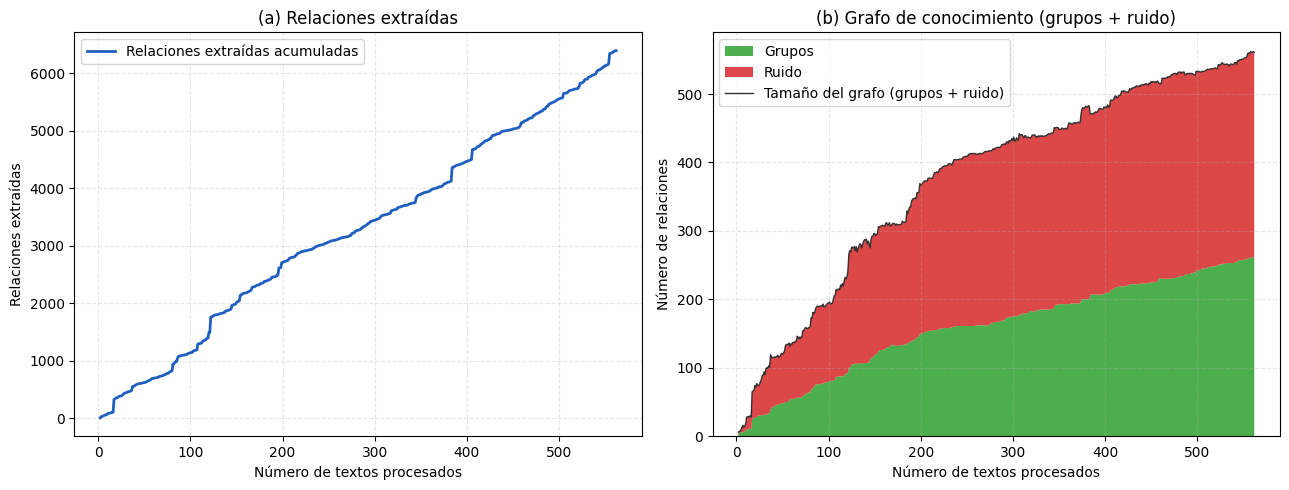

In [12]:
import matplotlib.pyplot as plt

x = df_resultados_iteraciones["iteration"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel izquierdo: relaciones extraídas ---
ax1.plot(x, df_resultados_iteraciones["total_relaciones"],
         linewidth=2, color="#1f5fbf", label="Relaciones extraídas acumuladas")
ax1.set_xlabel("Número de textos procesados")
ax1.set_ylabel("Relaciones extraídas")
ax1.grid(True, linestyle="--", alpha=0.3)
ax1.legend(loc="upper left")
ax1.set_title("(a) Relaciones extraídas")

# --- Panel derecho: evolución del grafo de conocimiento (apilado) ---
ax2.stackplot(
    x,
    df_resultados_iteraciones["total_clusters"],
    df_resultados_iteraciones["total_noise"],
    labels=["Grupos", "Ruido"],
    colors=["#2ca02c", "#d62728"],
    alpha=0.85
)
ax2.plot(x, df_resultados_iteraciones["total_relaciones_kg"],
         linewidth=1, color="#333333", label="Tamaño del grafo (grupos + ruido)")
ax2.set_xlabel("Número de textos procesados")
ax2.set_ylabel("Número de relaciones")
ax2.grid(True, linestyle="--", alpha=0.3)
ax2.legend(loc="upper left")
ax2.set_title("(b) Grafo de conocimiento (grupos + ruido)")

plt.tight_layout()
plt.savefig("exp5_evolucion.png", dpi=300, bbox_inches="tight")
plt.show()

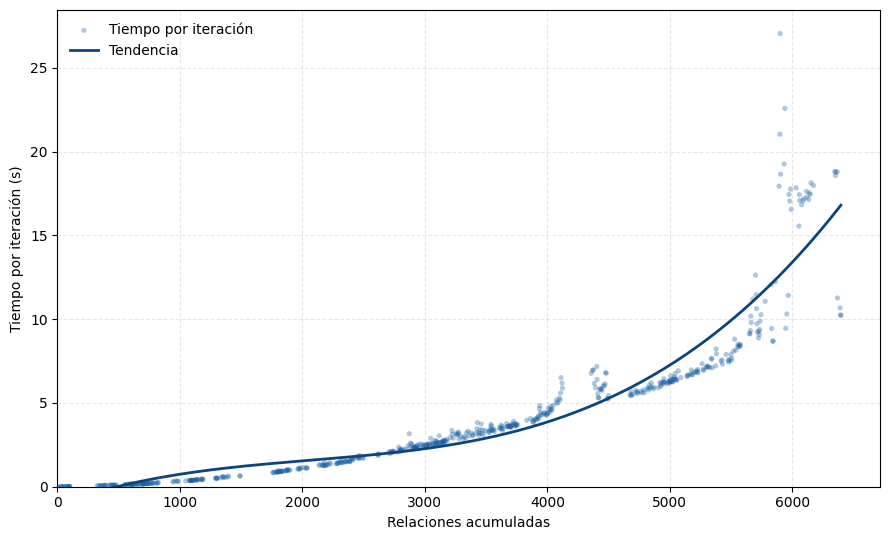

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el dataframe de resultados por iteración
df = pd.read_pickle("../Output/experiments/df_resultados_iteraciones_exp09_ortogonal_sinpca_20260628_191456.pkl")

# 2. Quedarse con las iteraciones que tienen tiempo medido y ordenarlas
val = df.dropna(subset=["tiempo_iteracion_segundos"]).sort_values("total_relaciones")

x = val["total_relaciones"].to_numpy()
y = val["tiempo_iteracion_segundos"].to_numpy()

# 3. Curva de ajuste: polinomio de grado 3 sobre la nube de puntos
coef = np.polyfit(x, y, deg=3)
x_linea = np.linspace(x.min(), x.max(), 200)
y_linea = np.polyval(coef, x_linea)

# 4. Dibujar
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(x, y, s=14, color="#185FA5", alpha=0.35, edgecolors="none",
           label="Tiempo por iteración")
ax.plot(x_linea, y_linea, color="#0C447C", linewidth=2,
        label="Tendencia")

ax.set_xlabel("Relaciones acumuladas")
ax.set_ylabel("Tiempo por iteración (s)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(loc="upper left", frameon=False)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("exp6_coste_computacional.png", dpi=300, bbox_inches="tight")
plt.savefig("exp6_coste_computacional.svg", bbox_inches="tight")
plt.show()

Figura guardada en: trayectoria_metricas.png  (4 paneles, mostrar='ambas')


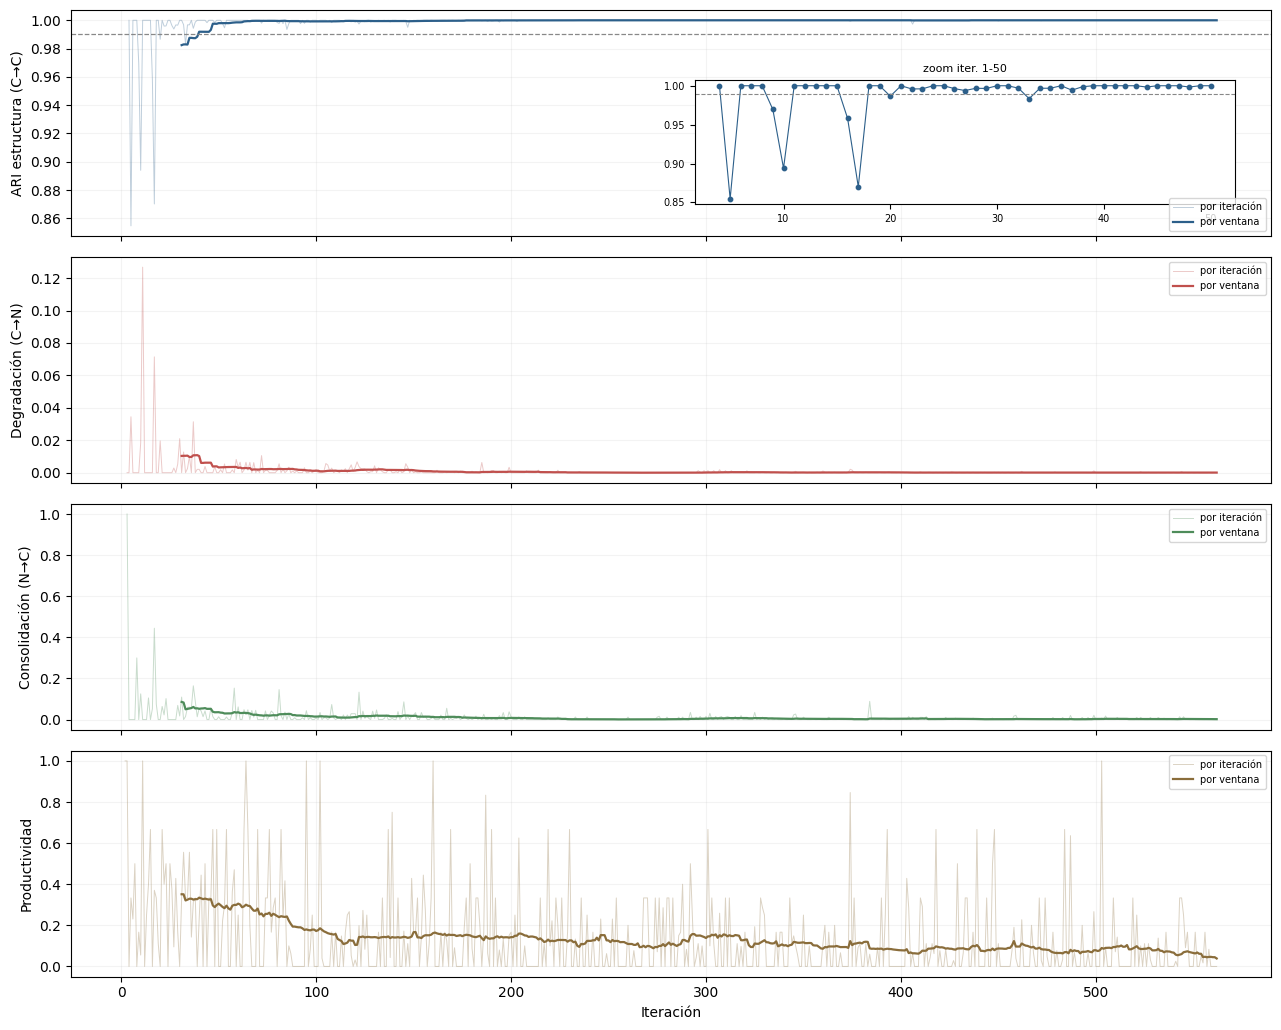

In [21]:
"""
Trayectoria de las métricas del criterio de parada, a partir del dataframe de
resultados por iteración.

Cada métrica existe en dos formas en el dataframe:
  - por ITERACIÓN: la señal cruda de cada paso.
  - por VENTANA  : la media móvil, que es la que usa la decisión de parada.

Por defecto se muestran ambas: la de iteración tenue y la de ventana gruesa.
Con `mostrar="ventana"` o `mostrar="iteracion"` se enseña solo una.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Configuración
# ---------------------------------------------------------------------------
ARI_UMBRAL = 0.99          # umbral de referencia que se dibuja en el panel ARI
ZOOM_MAX = 50              # rango de iteraciones del recuadro de zoom (panel ARI)
DELTA_YLIM = (-3, 6)       # recorte vertical del panel de delta de clusters
OUTPUT_PATH = "trayectoria_metricas.png"   # imagen de salida (None = no guardar)

COL_ITER = "iteration"

# Especificación de las métricas a dibujar: (etiqueta, col_iteracion, col_ventana,
# tipo, color). col_ventana=None -> la métrica no tiene forma de ventana.
METRICAS = [
    ("ARI estructura (C→C)",  "ari_estructura",                     "media_ari_estructura",                     "linea",  "#2c5f8a"),
    ("Degradación (C→N)",     "tasa_degradacion",                   "media_tasa_degradacion",                   "linea",  "#c0504d"),
    ("Consolidación (N→C)",   "tasa_consolidacion",                 "media_tasa_consolidacion",                 "linea",  "#4e8c5a"),
    ("Productividad",         "ratio_conocimiento_nuevo_iteracion", "ratio_productividad_conocimiento_ventana", "linea",  "#8a6d3b"),
]


def _panel_linea(ax, df, col_iter, col_vent, color, mostrar):
    if mostrar in ("ambas", "iteracion") and col_iter in df:
        ax.plot(df[COL_ITER], df[col_iter], lw=0.7, color=color,
                alpha=0.30 if mostrar == "ambas" else 0.9,
                label="por iteración")
    if mostrar in ("ambas", "ventana") and col_vent and col_vent in df:
        ax.plot(df[COL_ITER], df[col_vent], lw=1.6, color=color,
                label="por ventana")
    if mostrar == "ambas" and col_vent:
        ax.legend(fontsize=7, loc="best")


def _panel_barras(ax, df, col_iter, color):
    d = df.dropna(subset=[col_iter])
    colores = np.where(d[col_iter] >= 0, color, "#b94a48")
    ax.bar(d[COL_ITER], d[col_iter], width=1.0, color=colores)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylim(*DELTA_YLIM)


def _zoom_ari(ax, df, color):
    axz = ax.inset_axes([0.52, 0.14, 0.45, 0.55])
    dz = df[df[COL_ITER] <= ZOOM_MAX]
    axz.plot(dz[COL_ITER], dz["ari_estructura"], lw=0.8, color=color)
    axz.scatter(dz[COL_ITER], dz["ari_estructura"], s=10, color=color)
    axz.axhline(ARI_UMBRAL, ls="--", lw=0.8, color="#888")
    axz.set_title(f"zoom iter. 1-{ZOOM_MAX}", fontsize=8)
    axz.tick_params(labelsize=7)


def graficar_trayectoria_metricas(df, mostrar="ambas", output_path=OUTPUT_PATH,
                                  metricas=METRICAS):

    df = df.sort_values(COL_ITER).reset_index(drop=True)

    metricas = [m for m in metricas if m[1] in df.columns]
    n = len(metricas)
    fig, axes = plt.subplots(n, 1, figsize=(13, 2.6 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, (etq, col_it, col_vt, tipo, color) in zip(axes, metricas):
        if tipo == "barras":
            _panel_barras(ax, df, col_it, color)
        else:
            _panel_linea(ax, df, col_it, col_vt, color, mostrar)
            if col_it == "ari_estructura":
                ax.axhline(ARI_UMBRAL, ls="--", lw=0.9, color="#888")
                _zoom_ari(ax, df, color)
        ax.set_ylabel(etq)
        ax.grid(alpha=0.15)

    axes[-1].set_xlabel("Iteración")
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=130, bbox_inches="tight")
        print(f"Figura guardada en: {output_path}  ({n} paneles, mostrar='{mostrar}')")
    return fig


fig = graficar_trayectoria_metricas(df_resultados_iteraciones)
plt.show()

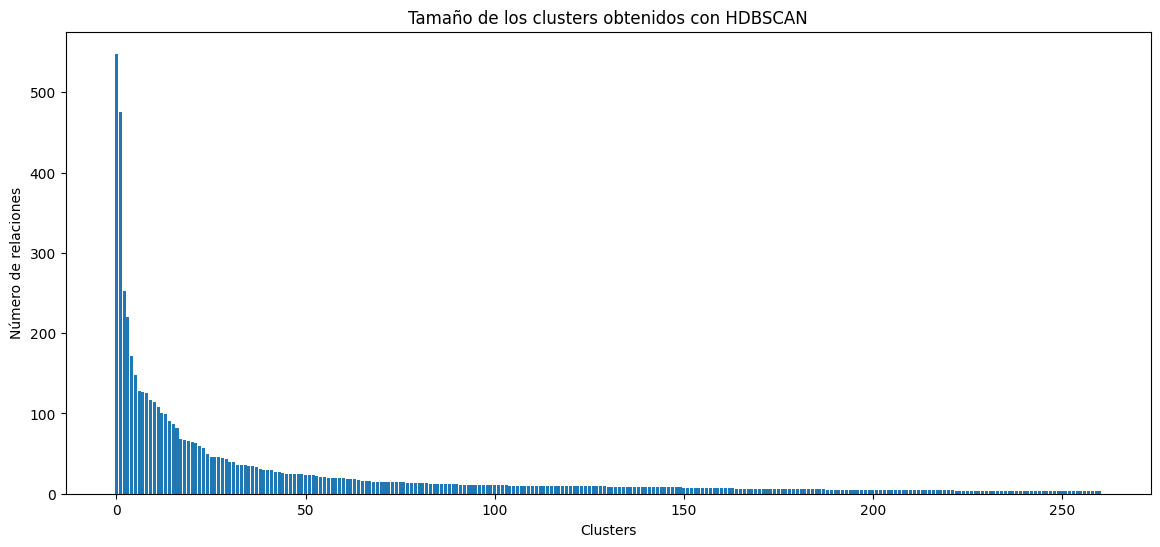

In [10]:
cluster_sizes = (
    df_triplets_final[df_triplets_final["cluster"] != -1]
    .groupby("cluster")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

plt.bar(
    range(len(cluster_sizes)),
    cluster_sizes.values
)

plt.xlabel("Clusters")
plt.ylabel("Número de relaciones")
plt.title("Tamaño de los clusters obtenidos con HDBSCAN")

plt.show()

In [9]:
df_triplets_final.describe

<bound method NDFrame.describe of          id                                     Nombre  Anyo  \
0      1294  López (del Corral), Paula (o Paula María)  1685   
1      1294  López (del Corral), Paula (o Paula María)  1685   
2      1294  López (del Corral), Paula (o Paula María)  1685   
3      7347                            León, Alonso de  1624   
4      7347                            León, Alonso de  1624   
...     ...                                        ...   ...   
12263  2460                            Vargas, Juan de  1625   
12264  2460                            Vargas, Juan de  1625   
12265  2460                            Vargas, Juan de  1625   
12266  2460                            Vargas, Juan de  1625   
12267  2460                            Vargas, Juan de  1625   

                                                   Frase  \
0      Paula López formó parte de la compañía de Féli...   
1      Paula López formó parte de la compañía de Féli...   
2      Paula Lópe

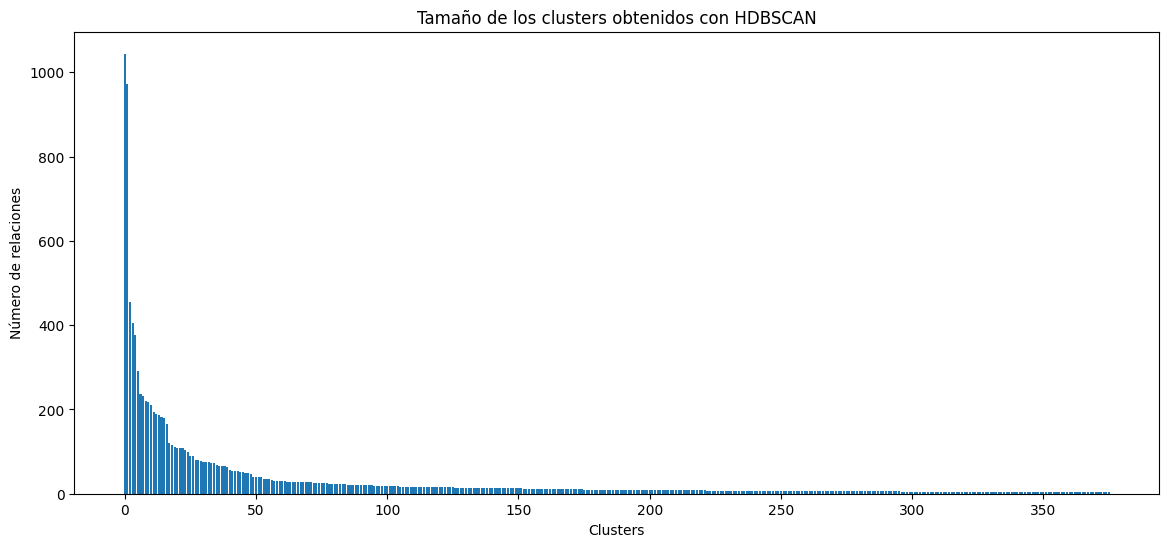

In [12]:
cluster_sizes = (
    df_triplets_final[df_triplets_final["cluster"] != -1]
    .groupby("cluster")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

plt.bar(
    range(len(cluster_sizes)),
    cluster_sizes.values
)

plt.xlabel("Clusters")
plt.ylabel("Número de relaciones")
plt.title("Tamaño de los clusters obtenidos con HDBSCAN")

plt.show()

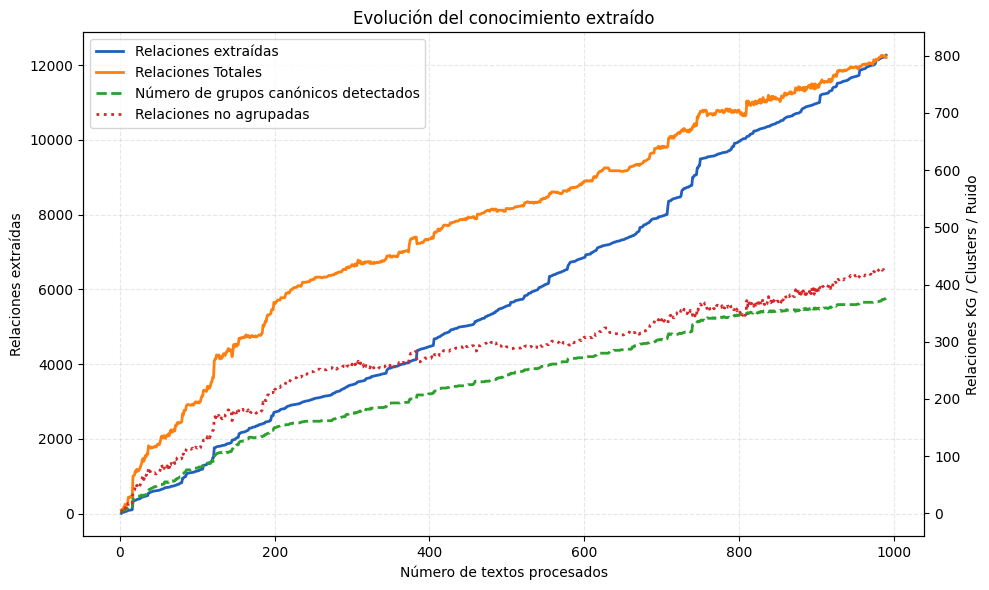

In [7]:
import matplotlib.pyplot as plt

x = df_resultados_iteraciones["iteration"]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje izquierdo
line1 = ax1.plot(
    x,
    df_resultados_iteraciones["total_relaciones"],
    linewidth=2,
    color="#1f5fbf",
    label="Relaciones extraídas"
)

ax1.set_xlabel("Número de textos procesados")
ax1.set_ylabel("Relaciones extraídas")

# Eje derecho
ax2 = ax1.twinx()

line2 = ax2.plot(
    x,
    df_resultados_iteraciones["total_relaciones_kg"],
    linewidth=2,
    color="#ff7f0e",
    label="Relaciones Totales"
)

line3 = ax2.plot(
    x,
    df_resultados_iteraciones["total_clusters"],
    linewidth=2,
    linestyle="--",
    color="#2ca02c",
    label="Número de grupos canónicos detectados"
)

line4 = ax2.plot(
    x,
    df_resultados_iteraciones["total_noise"],
    linewidth=2,
    linestyle=":",
    color="#d62728",
    label="Relaciones no agrupadas"
)

ax2.set_ylabel("Relaciones KG / Clusters / Ruido")

# Leyenda conjunta
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc="upper left")

ax1.grid(True, linestyle="--", alpha=0.3)

plt.title("Evolución del conocimiento extraído")

plt.tight_layout()

plt.savefig(
    "evolucion_conocimiento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

